# Problem 3.1

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [Intercept, Weights, Noise]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [Intercept, Weights]


Output()

/var/folders/hn/gx3zxz4516s7kxrlbtw0ygmh0000gp/T/ipykernel_5664/2379655525.py:76: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = az.hdi(mu_samples, hdi_prob=0.95)


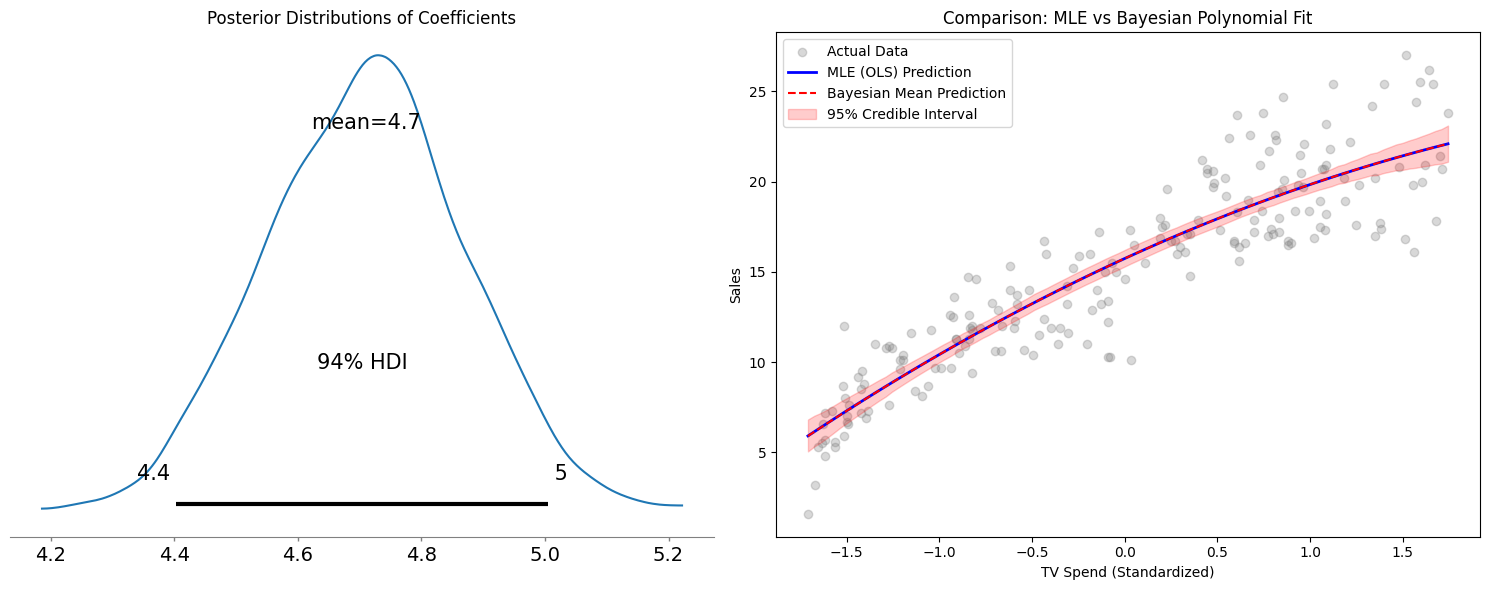

MLE Coefficients: Intercept=15.7409, Beta=[ 4.7076512  -0.61035158]

Bayesian Summary:
              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
Intercept   15.743  0.238  15.295   16.178      0.005    0.004    2232.0   
Weights[0]   4.709  0.162   4.403    5.004      0.003    0.003    3216.0   
Weights[1]  -0.612  0.179  -0.944   -0.272      0.004    0.003    2223.0   

            ess_tail  r_hat  
Intercept     2498.0    1.0  
Weights[0]    2856.0    1.0  
Weights[1]    2659.0    1.0  


In [1]:
import pymc as pm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# 1. LOAD AND PREPROCESS DATA
# Note: Ensure Advertising.csv is in your working directory
try:
    df = pd.read_csv('advertising.csv')
except FileNotFoundError:
    # Creating dummy data if file is missing for demonstration
    np.random.seed(42)
    x_dummy = np.random.uniform(0, 300, 200)
    y_dummy = 5 + 0.05*x_dummy + 0.0001*(x_dummy**2) + np.random.normal(0, 1, 200)
    df = pd.DataFrame({'TV': x_dummy, 'Sales': y_dummy})

X_raw = df['TV'].values.reshape(-1, 1)
y = df['Sales'].values

# Standardize features for MCMC stability
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).flatten()
X_poly = np.stack([X_scaled, X_scaled**2], axis=1)

# 2. FREQUENTIST OLS (MLE Equivalent)
mle_model = LinearRegression().fit(X_poly, y)
x_grid = np.linspace(X_scaled.min(), X_scaled.max(), 100).reshape(-1, 1)
x_grid_poly = np.concatenate([x_grid, x_grid**2], axis=1)
y_mle_pred = mle_model.predict(x_grid_poly)

# 3. BAYESIAN MODELING WITH PYMC
with pm.Model() as model:
    # Priors: Weekly informative Normal priors
    beta0 = pm.Normal("Intercept", mu=y.mean(), sigma=10)
    beta = pm.Normal("Weights", mu=0, sigma=10, shape=2)
    sigma = pm.Exponential("Noise", lam=1.0)
    
    # Linear combination
    mu = beta0 + beta[0] * X_poly[:, 0] + beta[1] * X_poly[:, 1]
    
    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)
    
    # Sampling
    trace = pm.sample(2000, tune=1000, chains=2, target_accept=0.95)

# 4. POSTERIOR PREDICTIVE FOR VISUALIZATION
with model:
    # Generate predictions across the grid
    mu_grid = beta0 + beta[0] * x_grid_poly[:, 0] + beta[1] * x_grid_poly[:, 1]
    post_pred = pm.sample_posterior_predictive(trace, var_names=["Intercept", "Weights"])
    
    # Extract posterior samples to manually plot credible intervals
    post_beta0 = trace.posterior["Intercept"].values.flatten()
    post_beta = trace.posterior["Weights"].values.reshape(-1, 2)
    
    # Calculate expected y (mu) for every posterior sample across the grid
    mu_samples = post_beta0[:, None] + (post_beta[:, 0, None] * x_grid_poly[:, 0]) + (post_beta[:, 1, None] * x_grid_poly[:, 1])

# 5. VISUALIZATION
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Posteriors
az.plot_posterior(trace, var_names=["Weights"], ax=ax[0])
ax[0].set_title("Posterior Distributions of Coefficients")

# Plot 2: Bayesian vs MLE Comparison
ax[1].scatter(X_scaled, y, alpha=0.3, label="Actual Data", color='gray')
ax[1].plot(x_grid, y_mle_pred, color='blue', lw=2, label="MLE (OLS) Prediction")

# Plot Bayesian mean and Credible Interval
mu_mean = mu_samples.mean(axis=0)
hdi = az.hdi(mu_samples, hdi_prob=0.95)
ax[1].plot(x_grid, mu_mean, color='red', linestyle='--', label="Bayesian Mean Prediction")
ax[1].fill_between(x_grid.flatten(), hdi[:, 0], hdi[:, 1], color='red', alpha=0.2, label="95% Credible Interval")

ax[1].set_title("Comparison: MLE vs Bayesian Polynomial Fit")
ax[1].set_xlabel("TV Spend (Standardized)")
ax[1].set_ylabel("Sales")
ax[1].legend()

plt.tight_layout()
plt.show()

# Print summary comparison
print(f"MLE Coefficients: Intercept={mle_model.intercept_:.4f}, Beta={mle_model.coef_}")
print("\nBayesian Summary:")
print(az.summary(trace, var_names=["Intercept", "Weights"]))

# Problem 3.2

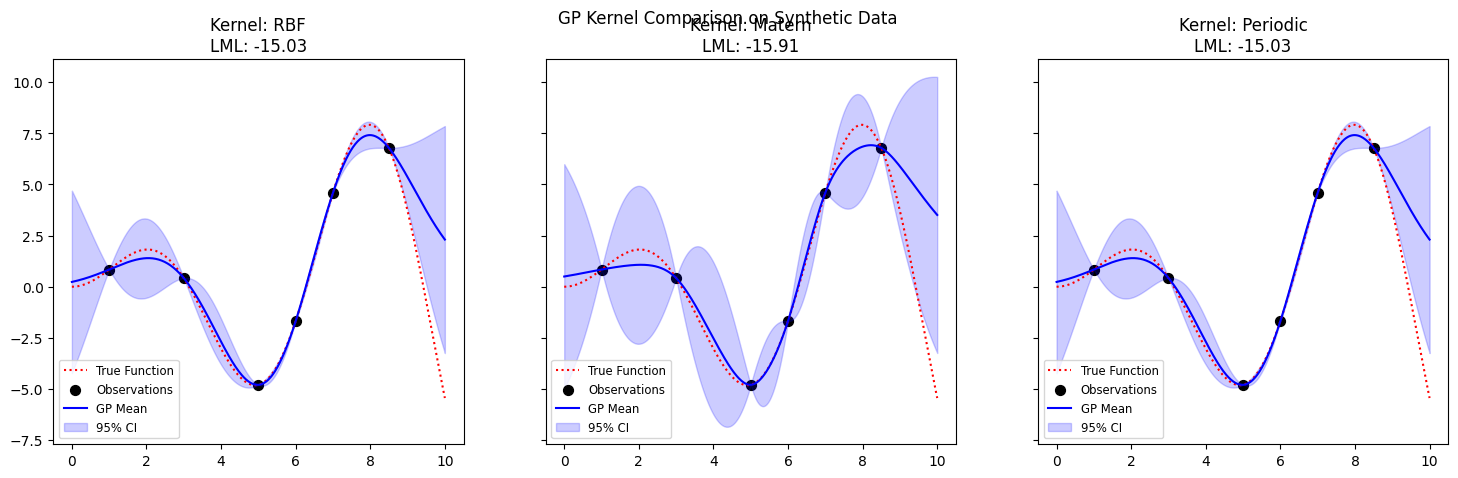

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ExpSineSquared, ConstantKernel, WhiteKernel
from sklearn.datasets import fetch_openml

# 1. SETUP: 1D SYNTHETIC DATA
def target_func(x):
    return x * np.sin(x)

X_train = np.array([1, 3, 5, 6, 7, 8.5]).reshape(-1, 1)
y_train = target_func(X_train).flatten()
x_plot = np.linspace(0, 10, 500).reshape(-1, 1)

# 2. KERNEL EXPERIMENTATION (1D)
np.random.seed(42)
kernels = [
    ("RBF", 1.0 * RBF(length_scale=1.0)),
    ("Matern", 1.0 * Matern(length_scale=1.0, nu=1.5)),
    ("Periodic", 1.0 * ExpSineSquared(length_scale=1.0, periodicity=3.0))
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (name, kernel) in zip(axes, kernels):
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
    gp.fit(X_train, y_train)
    y_pred, sigma = gp.predict(x_plot, return_std=True)
    
    ax.plot(x_plot, target_func(x_plot), 'r:', label="True Function")
    ax.scatter(X_train, y_train, c='black', s=50, label="Observations")
    ax.plot(x_plot, y_pred, 'b-', label="GP Mean")
    ax.fill_between(x_plot.flatten(), y_pred - 1.96*sigma, y_pred + 1.96*sigma, alpha=0.2, color='blue', label="95% CI")
    ax.set_title(f"Kernel: {name}\nLML: {gp.log_marginal_likelihood_value_:.2f}")
    ax.legend(loc='lower left', fontsize='small')

plt.suptitle("GP Kernel Comparison on Synthetic Data")
plt.show()

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


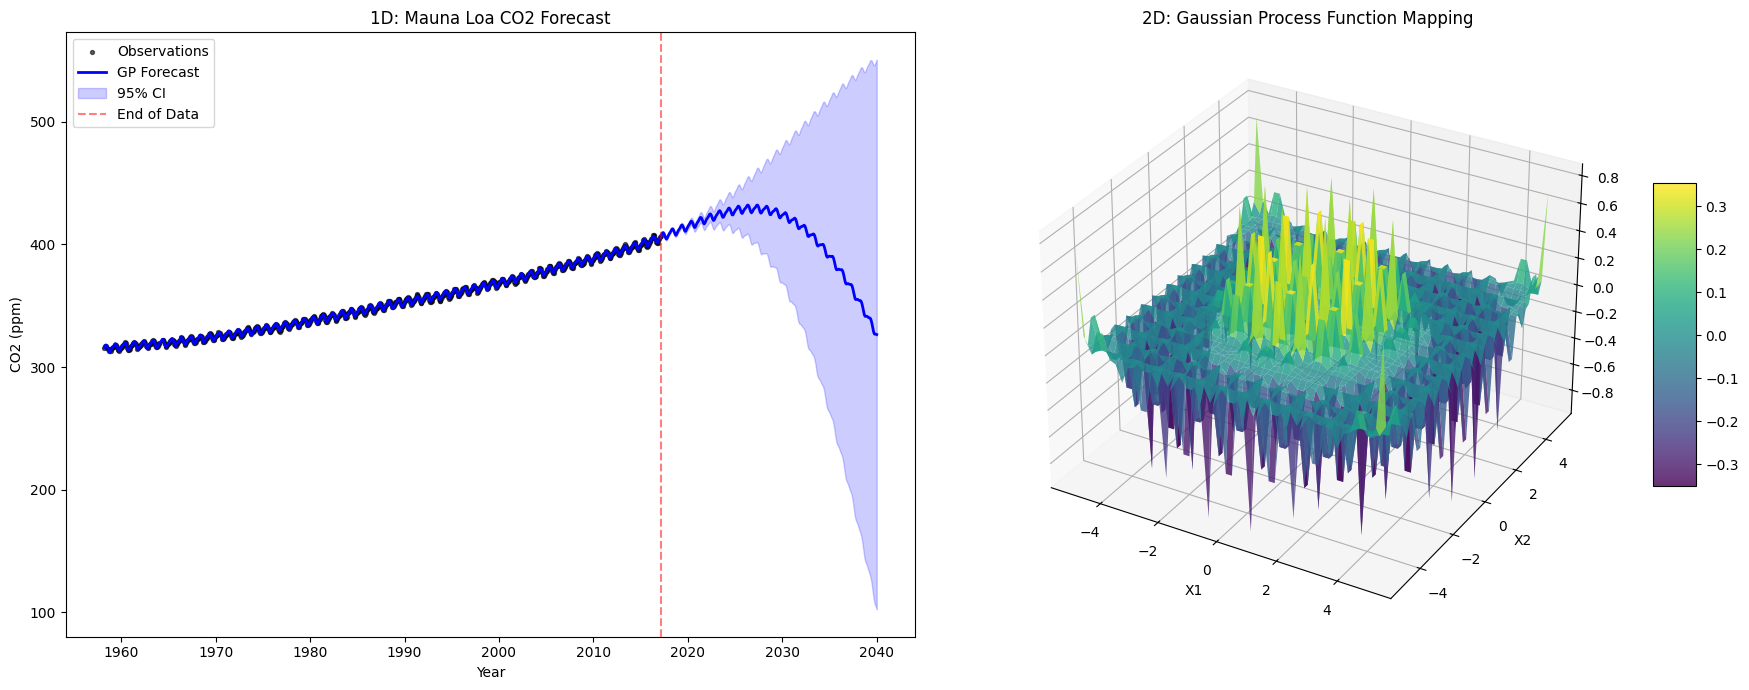

Optimized 1D Kernel: 236**2 * RBF(length_scale=15.3) + 2.24**2 * ExpSineSquared(length_scale=1.32, periodicity=1) + WhiteKernel(noise_level=0.219)


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, ConstantKernel as C

# --- 1. LOAD AND PREPARE 1D DATA (CO2) ---
df = pd.read_csv('archive.csv')
X_1d = df['Decimal Date'].values.reshape(-1, 1)
y_1d = df['Carbon Dioxide (ppm)'].values.flatten()

# Data Cleaning
mask = y_1d > 0
X_1d, y_1d = X_1d[mask], y_1d[mask]

# Subsample for speed (O(N^3) management)
step = max(1, len(X_1d) // 400)
X_1d_train, y_1d_train = X_1d[::step], y_1d[::step]

# --- 2. PREPARE 2D SYNTHETIC DATA ---
def f_2d(x):
    return np.sin(np.sqrt(x[:, 0]**2 + x[:, 1]**2))

# Create training points for 2D
x_coord = np.linspace(-5, 5, 15)
X1_train, X2_train = np.meshgrid(x_coord, x_coord)
X_2d_train = np.vstack([X1_train.ravel(), X2_train.ravel()]).T
y_2d_train = f_2d(X_2d_train)

# --- 3. FIT MODELS ---
# 1D Model (CO2)
kernel_1d = (
    C(50.0**2) * RBF(length_scale=50.0) + 
    C(2.0**2) * ExpSineSquared(length_scale=1.0, periodicity=1.0) + 
    WhiteKernel(noise_level=0.1)
)
gp_1d = GaussianProcessRegressor(kernel=kernel_1d, n_restarts_optimizer=5).fit(X_1d_train, y_1d_train)

# 2D Model (Surface)
gp_2d = GaussianProcessRegressor(kernel=C(1.0) * RBF(1.0)).fit(X_2d_train, y_2d_train)

# --- 4. PREDICTIONS ---
# 1D Prediction
X_1d_test = np.linspace(X_1d.min(), 2040, 1000).reshape(-1, 1)
y_1d_mean, y_1d_std = gp_1d.predict(X_1d_test, return_std=True)

# 2D Prediction Grid
grid_res = np.linspace(-5, 5, 50)
G1, G2 = np.meshgrid(grid_res, grid_res)
X_grid_2d = np.vstack([G1.ravel(), G2.ravel()]).T
y_pred_2d = gp_2d.predict(X_grid_2d).reshape(G1.shape)

# --- 5. VISUALIZATION ---
fig = plt.figure(figsize=(18, 7))

# Subplot 1: 1D CO2 Forecast
ax1 = fig.add_subplot(121)
ax1.scatter(X_1d_train, y_1d_train, c='black', s=8, alpha=0.6, label='Observations')
ax1.plot(X_1d_test, y_1d_mean, color='blue', lw=2, label='GP Forecast')
ax1.fill_between(X_1d_test.flatten(), y_1d_mean - 2*y_1d_std, y_1d_mean + 2*y_1d_std, 
                 color='blue', alpha=0.2, label='95% CI')
ax1.axvline(X_1d.max(), color='red', linestyle='--', alpha=0.5, label='End of Data')
ax1.set_title("1D: Mauna Loa CO2 Forecast")
ax1.set_xlabel("Year")
ax1.set_ylabel("CO2 (ppm)")
ax1.legend()

# Subplot 2: 2D Surface Plot
ax2 = fig.add_subplot(122, projection='3d')
surf = ax2.plot_surface(G1, G2, y_pred_2d, cmap='viridis', edgecolor='none', alpha=0.8)
ax2.set_title("2D: Gaussian Process Function Mapping")
ax2.set_xlabel("X1")
ax2.set_ylabel("X2")
fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=7)

plt.tight_layout()
plt.show()

print(f"Optimized 1D Kernel: {gp_1d.kernel_}")

# Problem 3.3

## Data

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

# download 3 years worth of data
data = yf.download('^GSPC', start='2020-01-01', end='2023-01-01')
prices = data['Close'].dropna()

prices.head()

[*********************100%***********************]  1 of 1 completed


Ticker,^GSPC
Date,
2020-01-02,3257.850098
2020-01-03,3234.850098
2020-01-06,3246.280029
2020-01-07,3237.179932
2020-01-08,3253.050049


## ARIMA model

ADF test
p-value: 0.5235


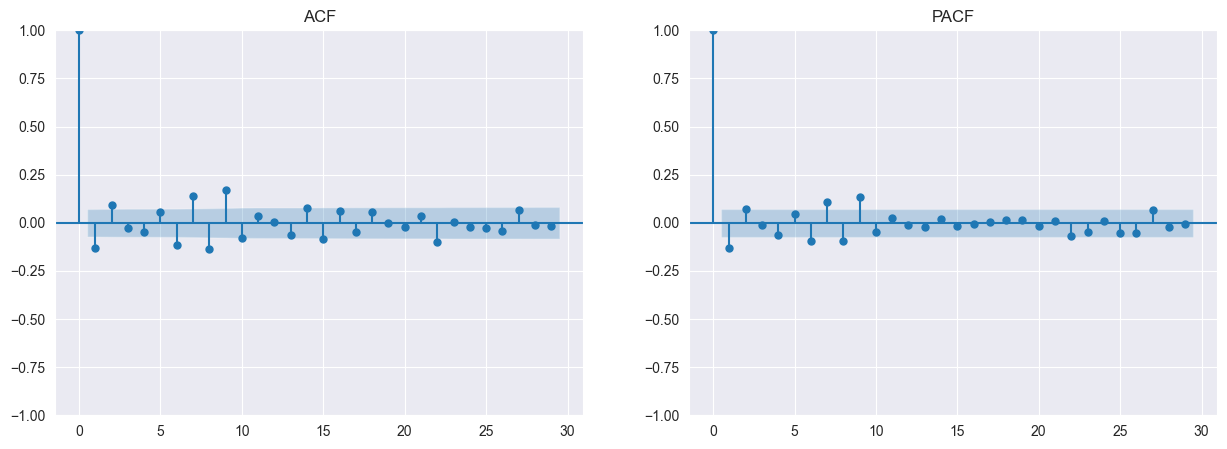

C:\Users\zawer\documents\applied_math\sem1\machine_learning\assingments\ml_assingments_venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\zawer\documents\applied_math\sem1\machine_learning\assingments\ml_assingments_venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\zawer\documents\applied_math\sem1\machine_learning\assingments\ml_assingments_venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\zawer\documents\applied_math\se

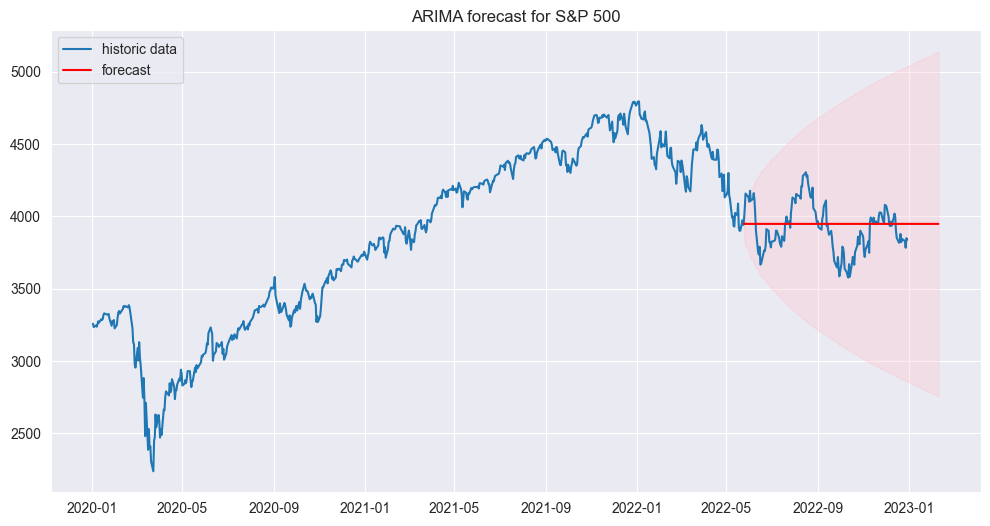

                               SARIMAX Results                                
Dep. Variable:                  ^GSPC   No. Observations:                  604
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3232.788
Date:                Sun, 26 Apr 2026   AIC                           6471.575
Time:                        18:10:54   BIC                           6484.781
Sample:                             0   HQIC                          6476.715
                                - 604                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4842      0.091     -5.297      0.000      -0.663      -0.305
ma.L1          0.2994      0.100      2.981      0.003       0.103       0.496
sigma2      2655.5719     89.518     29.665      0.0

In [6]:
# ADF test
print("ADF test")
adf_result = adfuller(prices)
print(f"p-value: {adf_result[1]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(prices.diff().dropna(), ax=ax1, title="ACF")
plot_pacf(prices.diff().dropna(), ax=ax2, title="PACF")
plt.show()

# split into test and train
split = int(len(prices) * 0.8)
train_prices, test_prices = prices.iloc[:split], prices.iloc[split:]

# fit ARIMA
model_arima = ARIMA(train_prices, order=(1, 1, 1))
res_arima = model_arima.fit()

# forecast
forecast_steps = len(test_prices) + 30
forecast_obj = res_arima.get_forecast(steps=forecast_steps)
forecast_mean = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

future_dates = pd.bdate_range(start=test_prices.index[-1] + pd.Timedelta(days=1), periods=30)
forecast_dates = test_prices.index.append(future_dates)

forecast_mean.index = forecast_dates
conf_int.index = forecast_dates

plt.figure(figsize=(12, 6))
plt.plot(prices.index, prices, label='historic data')
plt.plot(forecast_mean.index, forecast_mean, color='red', label='forecast')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title('ARIMA forecast for S&P 500')
plt.legend()
plt.show()

print(res_arima.summary())

# Problem 3.4

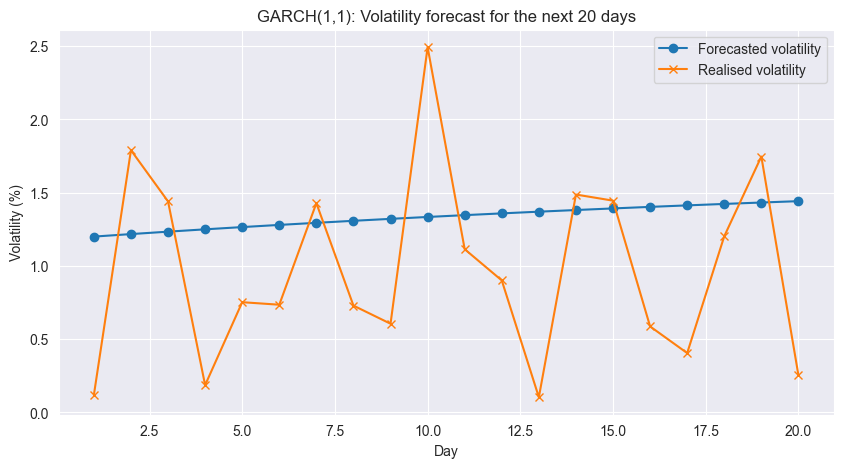

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  ^GSPC   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1225.92
Distribution:                  Normal   AIC:                           2459.84
Method:            Maximum Likelihood   BIC:                           2478.34
                                        No. Observations:                  755
Date:                Sun, Apr 26 2026   Df Residuals:                      754
Time:                        18:10:56   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0797  3.814e-02      2.090  3.665e-02 [4.947e-0

In [7]:
# calculating log-returns (*100 for better stability)
returns = prices.pct_change().dropna() * 100

# fitting GARCH(1,1)
model_garch = arch_model(returns, vol='Garch', p=1, q=1)
res_garch = model_garch.fit(disp='off')

# forecast for the next 20 days
forecast_garch = res_garch.forecast(horizon=20)
# calculating volatility
pred_vol = np.sqrt(forecast_garch.variance.values[-1, :])

# validation using realized volatility
realized_vol = np.abs(returns[-20:])

plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), pred_vol, marker='o', label='Forecasted volatility')
plt.plot(range(1, 21), realized_vol.values, marker='x', label='Realised volatility')
plt.title('GARCH(1,1): Volatility forecast for the next 20 days')
plt.xlabel('Day')
plt.ylabel('Volatility (%)')
plt.legend()
plt.show()

print(res_garch.summary())